### Train test split 

In [ ]:
# import os
# import shutil
# import random

# source_dir = "C:\\Users\\ussam\\OneDrive\\Desktop\\X_Ray\\Dataset"          # folder with 8 disease folders
# output_dir = "dataset"

# train_ratio = 0.7
# val_ratio = 0.10
# test_ratio = 0.10

# classes = os.listdir(source_dir)

# for cls in classes:

#     class_path = os.path.join(source_dir, cls)
#     images = os.listdir(class_path)
#     random.shuffle(images)

#     total = len(images)

#     train_end = int(total * train_ratio)
#     val_end = int(total * (train_ratio + val_ratio))

#     train_imgs = images[:train_end]
#     val_imgs = images[train_end:val_end]
#     test_imgs = images[val_end:]

#     for split, img_list in zip(
#         ["train", "val", "test"],
#         [train_imgs, val_imgs, test_imgs]
#     ):

#         split_folder = os.path.join(output_dir, split, cls)
#         os.makedirs(split_folder, exist_ok=True)

#         for img in img_list:
#             src = os.path.join(class_path, img)
#             dst = os.path.join(split_folder, img)
#             shutil.copy(src, dst)

# print("Dataset split completed.")

Dataset split completed.


### Balance Trian dataset
##### Using data augumentation

In [ ]:
# import os
# import random
# import numpy as np
# from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img

# train_dir = "dataset/train"

# datagen = ImageDataGenerator(
#     rotation_range=5,
#     width_shift_range=0.1,
#     height_shift_range=0.1,
#     zoom_range=0.1,
#     horizontal_flip=True,
#     fill_mode="nearest"
# )

# classes = os.listdir(train_dir)

# # find maximum class size
# class_counts = {}
# for cls in classes:
#     cls_path = os.path.join(train_dir, cls)
#     class_counts[cls] = len(os.listdir(cls_path))

# max_count = max(class_counts.values())
# print("Target images per class:", max_count)

# for cls in classes:

#     cls_path = os.path.join(train_dir, cls)
#     images = os.listdir(cls_path)

#     current_count = len(images)
#     needed = max_count - current_count

#     print(cls, "need", needed, "augmented images")

#     for i in range(needed):

#         img_name = random.choice(images)
#         img_path = os.path.join(cls_path, img_name)

#         img = load_img(img_path)
#         img_array = img_to_array(img)
#         img_array = np.expand_dims(img_array, axis=0)

#         aug_iter = datagen.flow(img_array, batch_size=1)

#         aug_img = next(aug_iter)[0].astype("uint8")

#         new_name = f"aug_{i}_{img_name}"
#         save_img(os.path.join(cls_path, new_name), aug_img)

# print("Dataset balanced with augmentation.")

Target images per class: 111
Atelectasis need 0 augmented images
Cardiomegaly need 17 augmented images
Effusion need 31 augmented images
Infiltrate need 41 augmented images
Mass need 57 augmented images
Nodule need 58 augmented images
Pneumonia need 29 augmented images
Pneumothorax need 43 augmented images
Dataset balanced with augmentation.


# Start it

#### Import liberies

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from torch.utils.tensorboard import SummaryWriter

import matplotlib.pyplot as plt
import seaborn as sns

#### path set

In [2]:
train_dir = "dataset/train"
test_dir  = "dataset/test"

#### Image Transform

In [3]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

#### Load dataset

In [4]:
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=transform)

class_names = train_dataset.classes
num_classes = len(class_names)

In [6]:
class_names

['Atelectasis',
 'Cardiomegaly',
 'Effusion',
 'Infiltrate',
 'Mass',
 'Nodule',
 'Pneumonia',
 'Pneumothorax']

#### Data Loader

In [7]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

#### Load ResNet Model

In [8]:
model = models.resnet50(pretrained=True)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

c:\Users\ussam\.conda\envs\new_ML\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\ussam\.conda\envs\new_ML\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\ussam/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100.0%


#### Loss & Optimizer

In [9]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.0001)

#### Learning Rate Scheduler

In [10]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer,
                mode='min',
                factor=0.3,
                patience=3
            )

#### TensorBoard Logger

In [11]:
writer = SummaryWriter("runs/xray_resnet")

#### Early Stopping Class

In [12]:
class EarlyStopping:

    def __init__(self, patience=5):

        self.patience = patience
        self.counter = 0
        self.best_loss = None
        self.stop = False

    def __call__(self, val_loss):

        if self.best_loss is None:
            self.best_loss = val_loss

        elif val_loss > self.best_loss:

            self.counter += 1

            if self.counter >= self.patience:
                self.stop = True

        else:
            self.best_loss = val_loss
            self.counter = 0

In [13]:
early_stop = EarlyStopping(patience=7)

#### Training Loop

In [14]:
epochs = 100

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    writer.add_scalar("Loss/train", train_loss, epoch)

    print(f"Epoch {epoch+1} Train Loss: {train_loss}")

    scheduler.step(train_loss)

    early_stop(train_loss)

    if early_stop.stop:
        print("Early stopping triggered")
        break

Epoch 1 Train Loss: 1.948634249823434
Epoch 2 Train Loss: 1.0283151247671671
Epoch 3 Train Loss: 0.23412354556577547
Epoch 4 Train Loss: 0.03989129726375852
Epoch 5 Train Loss: 0.014989796759826797
Epoch 6 Train Loss: 0.008780569528296058
Epoch 7 Train Loss: 0.006018916527474565
Epoch 8 Train Loss: 0.0049594407402245065
Epoch 9 Train Loss: 0.003595599052329947
Epoch 10 Train Loss: 0.003731438170819144
Epoch 11 Train Loss: 0.0027948693896178156
Epoch 12 Train Loss: 0.0030939178416571978
Epoch 13 Train Loss: 0.0019222174305468798
Epoch 14 Train Loss: 0.002288164009639461
Epoch 15 Train Loss: 0.0017849600241918648
Epoch 16 Train Loss: 0.0016383539269944386
Epoch 17 Train Loss: 0.0014865735034358554
Epoch 18 Train Loss: 0.00233633625820013
Epoch 19 Train Loss: 0.0016128627861949749
Epoch 20 Train Loss: 0.0012099895258350962
Epoch 21 Train Loss: 0.0016150414958246984
Epoch 22 Train Loss: 0.001518714138780654
Epoch 23 Train Loss: 0.0014838194256299175
Epoch 24 Train Loss: 0.00112196326101963

#### Save Model

In [16]:
torch.save(model.state_dict(), "resnet_xray_model.pth")

#### Evaluation

In [15]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs,1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

In [17]:
print("Accuracy:", accuracy_score(y_true, y_pred))

Accuracy: 0.292817679558011


In [18]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

 Atelectasis       0.33      0.25      0.29        32
Cardiomegaly       0.44      0.68      0.54        28
    Effusion       0.12      0.12      0.12        24
  Infiltrate       0.09      0.05      0.06        21
        Mass       0.00      0.00      0.00        16
      Nodule       0.26      0.44      0.33        16
   Pneumonia       0.26      0.25      0.26        24
Pneumothorax       0.39      0.45      0.42        20

    accuracy                           0.29       181
   macro avg       0.24      0.28      0.25       181
weighted avg       0.25      0.29      0.27       181



#### confusion_matrix

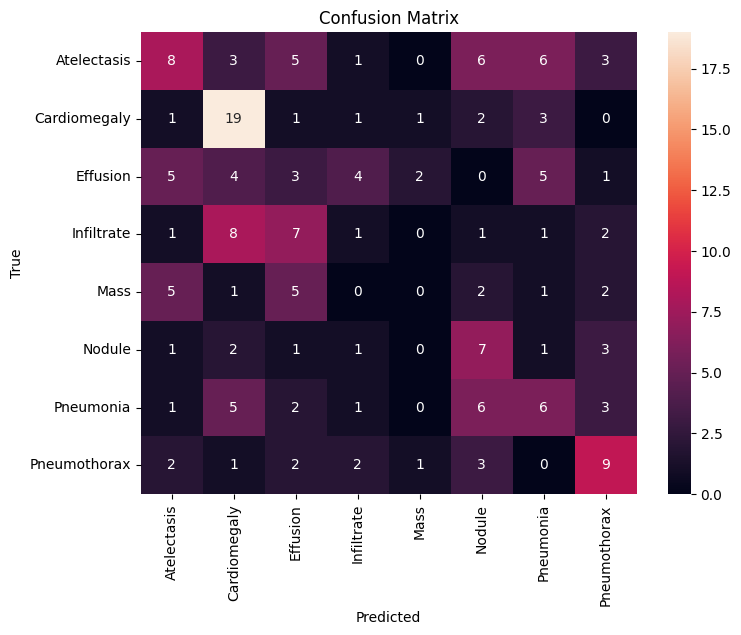

In [19]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

#### Grad-CAM Visualization

In [20]:
from torchcam.methods import SmoothGradCAMpp
from torchvision.transforms.functional import to_pil_image

cam_extractor = SmoothGradCAMpp(model)

model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)

outputs = model(images)

class_idx = outputs.argmax(dim=1)

activation_map = cam_extractor(class_idx.item(), outputs)

result = activation_map[0].squeeze().cpu()

plt.imshow(result, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.show()

RuntimeError: a Tensor with 32 elements cannot be converted to Scalar